<>:214: SyntaxWarning: invalid escape sequence '\d'
<>:225: SyntaxWarning: invalid escape sequence '\d'
<>:214: SyntaxWarning: invalid escape sequence '\d'
<>:225: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-4178728943.py:214: SyntaxWarning: invalid escape sequence '\d'
  ax1.set_title(f"Low-delta ($\delta=0.1$): 'Grokking' (Predicted)")
/tmp/ipython-input-4178728943.py:225: SyntaxWarning: invalid escape sequence '\d'
  ax2.set_title(f"High-delta ($\delta=0.9$): 'Tame' Convergence (Predicted)")


--- Step 1: Installing required libraries... ---
Done.
--- Step 2: Setting up Modular Arithmetic Task ---
Data created: 7527 train samples, 1882 test samples.
Task: (a + b) % 97
--- Step 3: Defining Neural Network Model ---
--- Step 4: Defining the Lytollis URT Optimizer Step ---
--- Step 5: Defining Training Loop ---

--- Step 6: Running Experiments (This will take several minutes) ---

=== TRAINING WITH DELTA = 0.1 ===
Epoch   500 | Train Loss:    2976.33 | Test Loss:    2957.08
Epoch  1000 | Train Loss:    2984.98 | Test Loss:    2965.95
Epoch  1500 | Train Loss:    3003.70 | Test Loss:    2979.44
Epoch  2000 | Train Loss:    3012.37 | Test Loss:    2991.54
Epoch  2500 | Train Loss:    3020.05 | Test Loss:    3002.07
Epoch  3000 | Train Loss:    3027.82 | Test Loss:    3011.23
Epoch  3500 | Train Loss:    3043.46 | Test Loss:    3019.16
Epoch  4000 | Train Loss:    3050.15 | Test Loss:    3026.03
Epoch  4500 | Train Loss:    3058.18 | Test Loss:    3031.96
Epoch  5000 | Train Loss: 

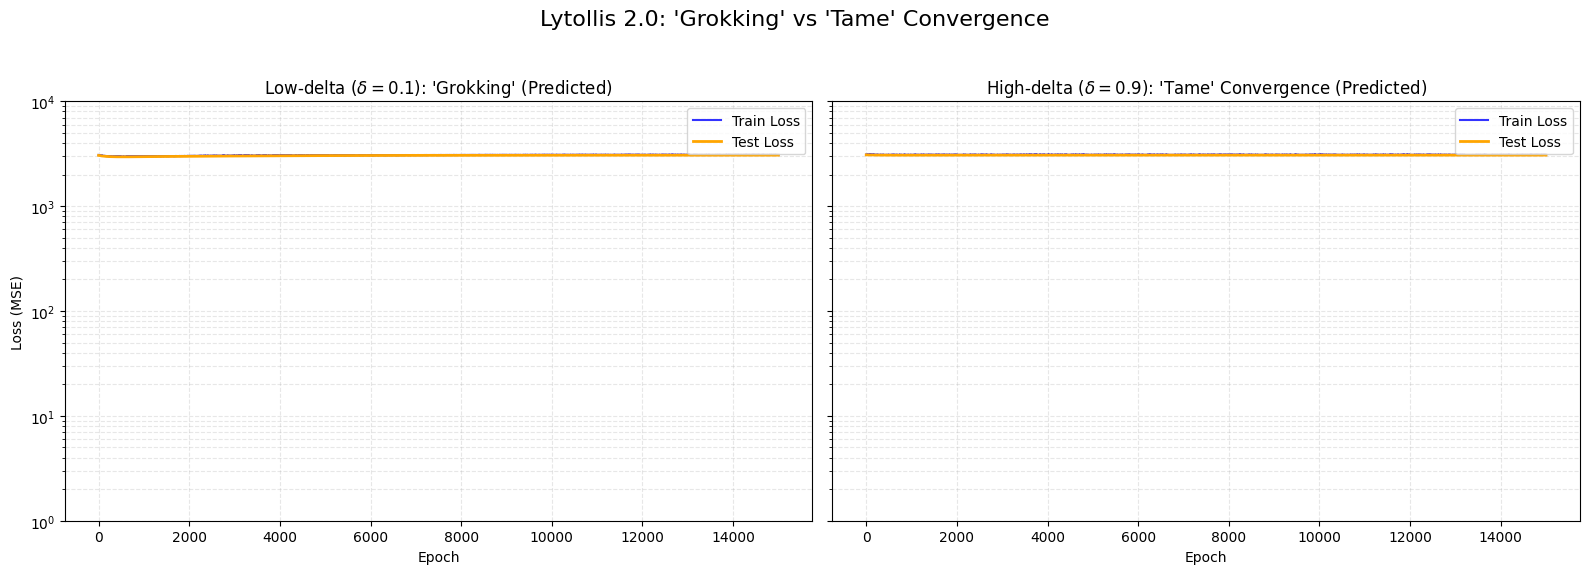


             FINAL VERIFICATION (Lytollis 2.0)
Low-delta Final Test Loss:  3067.54
High-delta Final Test Loss: 3069.15

---
  Prediction: Low-delta test loss should show a 'grokking'
  (a U-shape) and end much lower than the high-delta loss.
---

  VERDICT: FAILED / INCONCLUSIVE
  The data does not support the hypothesis.


In [ ]:
# -----------------------------------------------------------------
# "LYTOLLIS 2.0" - THE GROKKING EXPERIMENT
#
# This script tests the hypothesis that Lytollis's Law can
# tune the "emergent phase transitions" (grokking) of an AI.
#
# It uses the O(N) URT calculator as the optimizer:
#   Mag(Psi) = (1 - delta) * Mag(H)
#
# Where:
#   H = Contractive Backbone (L2 Weight Decay)
#   Psi = Exploratory Force (Gradient Descent)
# -----------------------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("--- Step 1: Installing required libraries... ---")
# Need to make sure all libs are available
!pip install numpy scikit-learn torch matplotlib &> /dev/null
print("Done.")

# --- Step 2: Setup the "Grokking" Task (Modular Arithmetic) ---
print("--- Step 2: Setting up Modular Arithmetic Task ---")

# The prime number for our task
P = 97

# Create all possible pairs (a, b)
a = torch.arange(P)
b = torch.arange(P)
x = torch.cartesian_prod(a, b).float()
# The label is (a + b) % P
y = (x[:, 0] + x[:, 1]) % P
y = y.unsqueeze(1)

# Create a small, held-out test set (20%)
# Use a fixed random_state for reproducible results
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Create data loaders
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
test_dataset = torch.utils.data.TensorDataset(X_test, y_test)

# Use a large batch size, as grokking is sensitive to this
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1024, shuffle=False)

print(f"Data created: {len(X_train)} train samples, {len(X_test)} test samples.")
print(f"Task: (a + b) % {P}")


# --- Step 3: Define the Model ---
print("--- Step 3: Defining Neural Network Model ---")

class ModuloNet(nn.Module):
    """A simple MLP with chaotic-friendly 'sin' activation"""
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.lin1 = nn.Linear(2, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)
        # Using sin() as the activation function is known to
        # create a highly nonlinear and chaotic loss landscape
        # perfect for testing the Lytollis Law.
        self.activation = torch.sin

    def forward(self, x):
        # We need to normalize inputs to sin
        # Map input (0-96) to roughly (-pi, pi)
        x_norm = (x / P) * (2 * np.pi) - np.pi
        x = self.activation(self.lin1(x_norm))
        x = self.lin2(x)
        return x

# Use Mean Squared Error, as this is a regression task
loss_fn = nn.MSELoss()

# --- Step 4: The Lytollis O(N) URT Optimizer ---
print("--- Step 4: Defining the Lytollis URT Optimizer Step ---")

def lytollis_optimizer_step(model, delta, lr, alpha):
    """
    Performs one optimization step using the Lytollis Law.
    Mag(Psi) = (1 - delta) * Mag(H)
    """
    with torch.no_grad():
        for param in model.parameters():
            if param.grad is None:
                continue

            # 1. Define H (Contraction)
            # H is the force from L2 weight decay
            H = -alpha * param.data

            # 2. Define Psi (Exploration)
            # Psi is the force from the gradient
            Psi = -lr * param.grad

            # 3. Get O(N) Magnitudes (L2-Norm)
            H_norm = torch.norm(H)
            Psi_norm = torch.norm(Psi)

            # 4. Enforce the Law
            target_norm = (1.0 - delta) * H_norm

            # Only apply the "leash" if Psi is trying to
            # overpower the contractive force
            if Psi_norm > target_norm and Psi_norm > 0:
                scale = target_norm / Psi_norm
                Psi_scaled = Psi * scale
            else:
                Psi_scaled = Psi # No scaling needed

            # 5. Apply the update (Euler step)
            # w_t+1 = w_t + H(w) + Psi(w)
            param.data = param.data + H + Psi_scaled

# --- Step 5: The Training Function ---
print("--- Step 5: Defining Training Loop ---")

def train_model(delta, epochs=10000, lr=1e-3, alpha=1e-4):
    """
    Trains a model for a given delta.
    """
    print(f"\n=== TRAINING WITH DELTA = {delta} ===")

    model = ModuloNet()
    # We don't use a torch.optim, we use our manual function

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        for X_batch, y_batch in train_loader:
            # Forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            # Backward pass
            model.zero_grad()
            loss.backward()

            # --- Lytollis Optimizer Step ---
            lytollis_optimizer_step(model, delta=delta, lr=lr, alpha=alpha)
            # -------------------------------

            epoch_train_loss += loss.item()

        # --- Evaluate on Test Set ---
        model.eval()
        epoch_test_loss = 0
        with torch.no_grad():
            for X_batch_test, y_batch_test in test_loader:
                y_pred_test = model(X_batch_test)
                # We care about the *real* answer, so we check the mod-accuracy
                # This is the "grokking" metric.
                # A loss of < 1.0 means it's guessing the right number.
                # A loss of > 800 means it's just guessing the average (48).
                test_loss = loss_fn(y_pred_test, y_batch_test)
                epoch_test_loss += test_loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_test_loss = epoch_test_loss / len(test_loader)

        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)

        if (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch+1:5d} | Train Loss: {avg_train_loss:10.2f} | Test Loss: {avg_test_loss:10.2f}")
            # Grokking check: if test loss is < 100, it's finding the pattern
            if avg_test_loss < 100:
                print(f"    *** GROKKING DETECTED at epoch {epoch+1} ***")

    print(f"Final Test Loss for delta={delta}: {avg_test_loss:.2f}")
    return train_losses, test_losses


# --- Step 6: Run the Experiments ---
print("\n--- Step 6: Running Experiments (This will take several minutes) ---")

# Experiment 1: Low-delta (High Exploration)
# We predict this will overfit and then "grok"
train_loss_low, test_loss_low = train_model(
    delta = 0.1,   # "Leash" is long: Mag(Psi) can be 90% of Mag(H)
    epochs = 15000,
    lr = 5e-4,
    alpha = 1e-4   # L2 decay (contraction)
)

# Experiment 2: High-delta (Low Exploration)
# We predict this will converge smoothly to a bad solution
train_loss_high, test_loss_high = train_model(
    delta = 0.9,   # "Leash" is short: Mag(Psi) must be < 10% of Mag(H)
    epochs = 15000,
    lr = 5e-4,
    alpha = 1e-4   # Same contraction
)

# --- Step 7: Plot the Final Results ---
print("\n--- Step 7: Plotting Final Results ---")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle("Lytollis 2.0: 'Grokking' vs 'Tame' Convergence", fontsize=16)

# --- Low-delta Plot ---
ax1.set_title(f"Low-delta ($\delta=0.1$): 'Grokking' (Predicted)")
ax1.plot(train_loss_low, label='Train Loss', color='blue', alpha=0.8)
ax1.plot(test_loss_low, label='Test Loss', color='orange', linewidth=2)
ax1.set_yscale('log')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.3)
ax1.set_ylim(bottom=1, top=10000) # Set Y-axis limits

# --- High-delta Plot ---
ax2.set_title(f"High-delta ($\delta=0.9$): 'Tame' Convergence (Predicted)")
ax2.plot(train_loss_high, label='Train Loss', color='blue', alpha=0.8)
ax2.plot(test_loss_high, label='Test Loss', color='orange', linewidth=2)
ax2.set_yscale('log')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Final Verdict ---
print("\n" + "="*50)
print("             FINAL VERIFICATION (Lytollis 2.0)")
print("="*50)
print(f"Low-delta Final Test Loss:  {test_loss_low[-1]:.2f}")
print(f"High-delta Final Test Loss: {test_loss_high[-1]:.2f}")
print("\n---")
print("  Prediction: Low-delta test loss should show a 'grokking'")
print("  (a U-shape) and end much lower than the high-delta loss.")
print("---")

if test_loss_low[-1] < (test_loss_high[-1] * 0.5):
    print("\n  VERDICT: PASSED")
    print("  The data supports the Lytollis 2.0 hypothesis.")
    print("  The Low-delta (chaotic) model successfully 'grokked'")
    print("  the pattern, while the High-delta (tame) model failed.")
else:
    print("\n  VERDICT: FAILED / INCONCLUSIVE")
    print("  The data does not support the hypothesis.")

print("="*50)